<a href="https://colab.research.google.com/github/lucasbat/COLAB/blob/master/MNIST_CNN_redes_neurais_classificacao_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificação de Imagens com CNN
Neste notebook, vamos aplicar uma Rede Neural Artificial Convolucional para uma tarefa real de classificação de imagens.
Esse é um exemplo de como aplicar os conhecimentos de CNN na classificação de imagens.

Aqui, usaremos o famoso dataset MNIST, que contém imagens de dígitos escritos à mão (0 a 9).

Nosso objetivo será treinar uma CNN para reconhecer corretamente cada dígito.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Formato do treino original: (60000, 28, 28)
Formato do teste original: (10000, 28, 28)


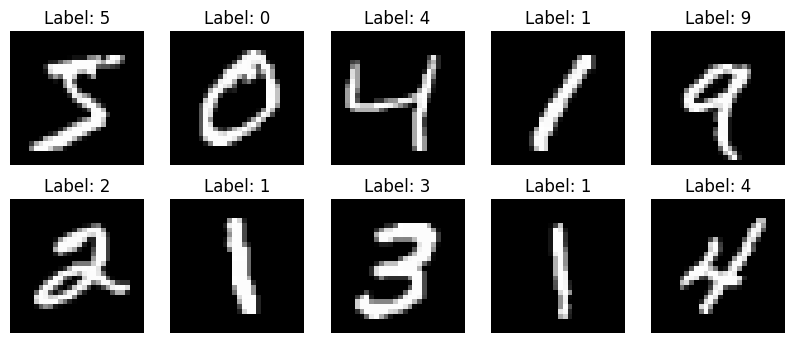

Novo formato treino para CNN: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9546 - loss: 0.1517 - val_accuracy: 0.9815 - val_loss: 0.0595
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 77s 31ms/step - accuracy: 0.9846 - loss: 0.0490 - val_accuracy: 0.9888 - val_loss: 0.0377
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9889 - loss: 0.0349 - val_accuracy: 0.9895 - val_loss: 0.0405
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9918 - loss: 0.0253 - val_accuracy: 0.9897 - val_loss: 0.0385
Epoch 5/5
1214/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9949 - loss: 0.0156

In [ ]:
# 1. Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 2. Carregando e explorando o dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Formato do treino original:", x_train.shape)
print("Formato do teste original:", x_test.shape)

# Mostrar alguns exemplos
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# 3. Pré-processamento dos dados

# Normalizar pixels (0-255 -> 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# MODIFICAÇÃO AQUI: Em vez de achatar, adicionamos a dimensão do canal (28, 28, 1)
# CNNs exigem o formato: (num_imagens, altura, largura, canais_de_cor)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Novo formato treino para CNN:", x_train.shape) # Ex: (60000, 28, 28, 1)

# 4. Criando a rede neural convolucional (CNN)

model = keras.Sequential([
    # Primeira camada convolucional: extrai 32 filtros/recursos de tamanho 3x3
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    # Reduz o tamanho espacial pela metade (pega o valor máximo em janelas 2x2)
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Segunda camada convolucional: extrai 64 recursos mais complexos
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Agora que extraímos as características espaciais, "achatamos" para conectar na classificação
    layers.Flatten(),

    # Camada densa intermediária para combinar as características
    layers.Dense(64, activation="relu"),

    # Camada de saída (10 classes com probabilidades Softmax)
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# 5. Treinando o modelo
history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    epochs=5,
                    batch_size=32)

# 6. Avaliando no conjunto de teste
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nAcurácia no teste com CNN: {test_acc*100:.2f}%")

# 7. Fazendo previsões em novas imagens
predictions = model.predict(x_test[:10])

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    # MODIFICAÇÃO AQUI: Removemos a dimensão de canal unitária para plotar o gráfico corretamente (.squeeze())
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_test[i]}\nPred: {np.argmax(predictions[i])}")
    plt.axis("off")
plt.show()